In [1]:
import torch

import sys
sys.path.append('../../src')
sys.path.append('/shared_data0/weiqiuy/api_keys')
from data_utils import get_nsf_data_proc
from model_utils import get_model
from eval_utils import Metrics, evaluate_model

ROOT_DIR = '/shared_data0/weiqiuy/nsf-awards'
debug = True

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# [tech2nontech] Technical Abstract to Nontechnical Abstract

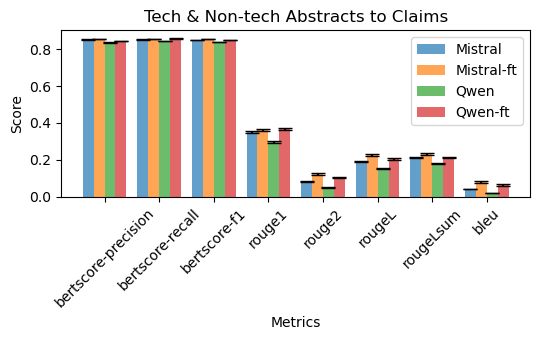

In [55]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import plot_grouped_bar_adjustable_width, bootstrap_std

def aggregate_and_analyze(results):
    """
    Takes a list of result dicts and returns a dictionary of
    {metric_name: (mean, std)} pairs. 
    """
    # Prepare containers for each metric
    metrics = {
        "bertscore-precision": [],
        "bertscore-recall": [],
        "bertscore-f1": [],
        "rouge1": [],
        "rouge2": [],
        "rougeL": [],
        "rougeLsum": [],
        "bleu": []
    }
    
    # Aggregate all values
    for res in results:
        # BERTScore can come in lists; extend or append accordingly
        metrics["bertscore-precision"].extend(res["bertscore"]["precision"])
        metrics["bertscore-recall"].extend(res["bertscore"]["recall"])
        metrics["bertscore-f1"].extend(res["bertscore"]["f1"])
        
        # ROUGE are single floats
        metrics["rouge1"].append(res["rouge"]["rouge1"])
        metrics["rouge2"].append(res["rouge"]["rouge2"])
        metrics["rougeL"].append(res["rouge"]["rougeL"])
        metrics["rougeLsum"].append(res["rouge"]["rougeLsum"])
        
        # BLEU is also a single float
        metrics["bleu"].append(res["bleu"]["bleu"])
    
    # Now compute mean and bootstrap std for each metric
    analysis = {}
    for metric_name, values in metrics.items():
        mean_val = np.mean(values)
        std_val = bootstrap_std(values, n_bootstrap=1000, seed=42)
        analysis[metric_name] = (mean_val, std_val)
    
    return analysis

load_dir = '../../results/tech2nontech'

name_mapping = {
    "mistral-7b-instruct-v0.3": "Mistral",
    "lora_model_mistral-7b-instruct-v0.3_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm": "Mistral-ft",
    "Qwen2.5-7B-Instruct": "Qwen",
    "lora_model_Qwen2.5-7B-Instruct_r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_emb_lm": "Qwen-ft"
}

all_model_basenames = [model_name for model_name in name_mapping]

results_all = {}
for model_basename in all_model_basenames:
    
    with open(os.path.join(load_dir, model_basename + '.json'), 'rt') as input_file:
        results_all[model_basename] = json.load(input_file)
    
    
results_all_aggr = {}
for key in results_all:
    aggr_results = aggregate_and_analyze(results_all[key])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, save_path='../figures/tech2nontech.pdf',
                                 name_mapping=name_mapping, figsize=(5.5, 3.5),
                                 rotation=45, ha='center',
                                 title='Tech & Non-tech Abstracts to Claims')

In [56]:
# Define the order of metrics to appear in the table rows
metric_order = [
    "bertscore-precision", "bertscore-recall", "bertscore-f1",
    "rouge1", "rouge2", "rougeL", "rougeLsum", "bleu"
]

# We'll use the keys of name_mapping to determine the model order in the table
model_keys = list(name_mapping.keys())
mapped_names = [name_mapping[k] for k in model_keys]

# Build the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
# Define column alignment: one for metric names (l) and one for each model (c)
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")
# Header row
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Helper function to format the value and uncertainty; optionally bold the result.
def format_value(val, unc, precision=4, bold=False):
    s = f"{val:.{precision}f} $\\pm$ {unc:.{precision}f}"
    return f"\\textbf{{{s}}}" if bold else s

# Start building the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")

# Header row with mapped model names
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Create a table row for each metric
for metric in metric_order:
    # Create a human-friendly metric label (capitalize first letter)
    metric_label = metric.capitalize()
    row_entries = [metric_label]
    
    # Find the maximum value for this metric among all models
    max_value = max(results_all_aggr[model][metric][0] for model in model_keys)
    
    # For each model, format the cell and bold it if it holds the max value
    for model in model_keys:
        value, uncertainty = results_all_aggr[model][metric]
        # Use a tolerance for float comparison
        is_max = abs(value - max_value) < 1e-8
        row_entries.append(format_value(value, uncertainty, bold=is_max))
    
    latex_lines.append(" & ".join(row_entries) + r" \\")
    
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\caption{Evaluation metrics for each model.}")
latex_lines.append(r"\label{tab:eval_metrics}")
latex_lines.append(r"\end{table}")

# Combine and print the LaTeX table
latex_table = "\n".join(latex_lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & Mistral & Mistral-ft & Qwen & Qwen-ft \\
\midrule
Bertscore-precision & 0.8531 $\pm$ 0.0005 & \textbf{0.8563 $\pm$ 0.0008} & 0.8377 $\pm$ 0.0005 & 0.8459 $\pm$ 0.0005 \\
Bertscore-recall & 0.8530 $\pm$ 0.0005 & 0.8566 $\pm$ 0.0006 & 0.8461 $\pm$ 0.0005 & \textbf{0.8597 $\pm$ 0.0005} \\
Bertscore-f1 & 0.8529 $\pm$ 0.0004 & \textbf{0.8561 $\pm$ 0.0007} & 0.8417 $\pm$ 0.0004 & 0.8526 $\pm$ 0.0004 \\
Rouge1 & 0.3497 $\pm$ 0.0021 & 0.3599 $\pm$ 0.0028 & 0.2965 $\pm$ 0.0018 & \textbf{0.3656 $\pm$ 0.0022} \\
Rouge2 & 0.0819 $\pm$ 0.0013 & \textbf{0.1243 $\pm$ 0.0027} & 0.0497 $\pm$ 0.0007 & 0.1038 $\pm$ 0.0021 \\
Rougel & 0.1880 $\pm$ 0.0013 & \textbf{0.2266 $\pm$ 0.0023} & 0.1536 $\pm$ 0.0009 & 0.2044 $\pm$ 0.0018 \\
Rougelsum & 0.2121 $\pm$ 0.0016 & \textbf{0.2319 $\pm$ 0.0025} & 0.1817 $\pm$ 0.0012 & 0.2118 $\pm$ 0.0020 \\
Bleu & 0.0404 $\pm$ 0.0011 & \textbf{0.0785 $\pm$ 0.0025} & 0.0179 $\pm$ 0.0007 & 0.0620 $\pm$ 0.00

In [30]:
# results_all

In [31]:
# results_all['mistral-7b-instruct-v0.3'][0]['preds']

# [technontech2claims] Techincal Abstract and Nontechnical Abstract to Verifiable Claims

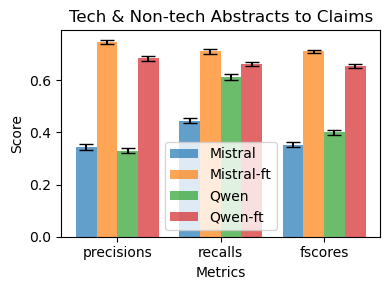

In [57]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std


name_mapping = {
    "mistral-7b-instruct-v0.3_preds": "Mistral",
    "lora_model_mistral-7b-instruct-v0.3.technontech2claims_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds": "Mistral-ft",
    "Qwen2.5-7B-Instruct_preds": "Qwen",
    "lora_model_Qwen2.5-7B-Instruct.technontech2claims_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds": "Qwen-ft"
}

results_path = '../../metrics/technontech2claims_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, 
                                  save_path='../figures/technontech2claims.pdf',
                                 name_mapping=name_mapping, figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to Claims')

In [58]:
# Define the order of metrics for the table rows
metric_order = ["precisions", "recalls", "fscores"]

# Get the model order from the keys in name_mapping
model_keys = list(name_mapping.keys())
mapped_names = [name_mapping[k] for k in model_keys]

# Start building the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
# One left-aligned column for the metric names and centered columns for each model
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")

# Header row with mapped model names
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Helper function to format the value and uncertainty; optionally bold the result.
def format_value(val, unc, precision=4, bold=False):
    s = f"{val:.{precision}f} $\\pm$ {unc:.{precision}f}"
    return f"\\textbf{{{s}}}" if bold else s

# Start building the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")

# Header row with mapped model names
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Create a table row for each metric
for metric in metric_order:
    # Create a human-friendly metric label (capitalize first letter)
    metric_label = metric.capitalize()
    row_entries = [metric_label]
    
    # Find the maximum value for this metric among all models
    max_value = max(results_all_aggr[model][metric][0] for model in model_keys)
    
    # For each model, format the cell and bold it if it holds the max value
    for model in model_keys:
        value, uncertainty = results_all_aggr[model][metric]
        # Use a tolerance for float comparison
        is_max = abs(value - max_value) < 1e-8
        row_entries.append(format_value(value, uncertainty, bold=is_max))
    
    latex_lines.append(" & ".join(row_entries) + r" \\")
    
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\caption{Technical and Non-technical Abstracts to Claims.}")
latex_lines.append(r"\label{tab:eval_metrics}")
latex_lines.append(r"\end{table}")

# Combine all lines into one LaTeX table string and print
latex_table = "\n".join(latex_lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & Mistral & Mistral-ft & Qwen & Qwen-ft \\
\midrule
Precisions & 0.3438 $\pm$ 0.0053 & \textbf{0.7450 $\pm$ 0.0042} & 0.3302 $\pm$ 0.0044 & 0.6839 $\pm$ 0.0048 \\
Recalls & 0.4451 $\pm$ 0.0055 & \textbf{0.7098 $\pm$ 0.0044} & 0.6131 $\pm$ 0.0055 & 0.6611 $\pm$ 0.0045 \\
Fscores & 0.3516 $\pm$ 0.0050 & \textbf{0.7097 $\pm$ 0.0038} & 0.4005 $\pm$ 0.0047 & 0.6541 $\pm$ 0.0043 \\
\bottomrule
\end{tabular}
\caption{Technical and Non-technical Abstracts to Claims.}
\label{tab:eval_metrics}
\end{table}


# [technontech2ip] Technical Abstract and Nontechnical Abstract to Investigation Proposals

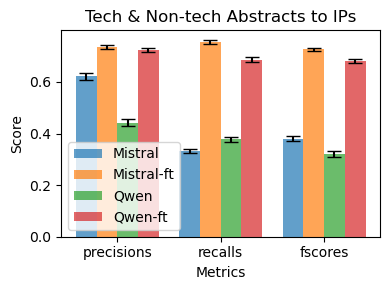

In [59]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std


name_mapping = {
    "mistral-7b-instruct-v0.3_preds": "Mistral",
    "lora_model_mistral-7b-instruct-v0.3.technontech2ip_instruct_user_assistant.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds": "Mistral-ft",
    "Qwen2.5-7B-Instruct_preds": "Qwen",
    "lora_model_Qwen2.5-7B-Instruct.technontech2ip_instruct.r128_la64_lr1e-05_e3_s-1_wu100_bs2_schlinear_optadamw_8bit_emb_lm_preds": "Qwen-ft"
}

results_path = '../../metrics/technontech2ip_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr, 
                                  save_path='../figures/technontech2ip.pdf',
                                 name_mapping=name_mapping, figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to IPs')

In [60]:
# Define the order of metrics for the table rows
metric_order = ["precisions", "recalls", "fscores"]

# Get the model order from the keys in name_mapping
model_keys = list(name_mapping.keys())
mapped_names = [name_mapping[k] for k in model_keys]

# Start building the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
# One left-aligned column for the metric names and centered columns for each model
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")

# Header row with mapped model names
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Helper function to format the value and uncertainty; optionally bold the result.
def format_value(val, unc, precision=4, bold=False):
    s = f"{val:.{precision}f} $\\pm$ {unc:.{precision}f}"
    return f"\\textbf{{{s}}}" if bold else s

# Start building the LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{" + "l" + "c" * len(model_keys) + r"}")
latex_lines.append(r"\toprule")

# Header row with mapped model names
header = "Metric & " + " & ".join(mapped_names) + r" \\"
latex_lines.append(header)
latex_lines.append(r"\midrule")

# Create a table row for each metric
for metric in metric_order:
    # Create a human-friendly metric label (capitalize first letter)
    metric_label = metric.capitalize()
    row_entries = [metric_label]
    
    # Find the maximum value for this metric among all models
    max_value = max(results_all_aggr[model][metric][0] for model in model_keys)
    
    # For each model, format the cell and bold it if it holds the max value
    for model in model_keys:
        value, uncertainty = results_all_aggr[model][metric]
        # Use a tolerance for float comparison
        is_max = abs(value - max_value) < 1e-8
        row_entries.append(format_value(value, uncertainty, bold=is_max))
    
    latex_lines.append(" & ".join(row_entries) + r" \\")
    
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\caption{Technical and Non-technical Abstracts to Investigation Proposals.}")
latex_lines.append(r"\label{tab:eval_metrics}")
latex_lines.append(r"\end{table}")

# Combine all lines into one LaTeX table string and print
latex_table = "\n".join(latex_lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & Mistral & Mistral-ft & Qwen & Qwen-ft \\
\midrule
Precisions & 0.6217 $\pm$ 0.0070 & \textbf{0.7351 $\pm$ 0.0041} & 0.4426 $\pm$ 0.0073 & 0.7245 $\pm$ 0.0045 \\
Recalls & 0.3317 $\pm$ 0.0047 & \textbf{0.7539 $\pm$ 0.0040} & 0.3781 $\pm$ 0.0051 & 0.6865 $\pm$ 0.0046 \\
Fscores & 0.3802 $\pm$ 0.0053 & \textbf{0.7261 $\pm$ 0.0036} & 0.3211 $\pm$ 0.0054 & 0.6827 $\pm$ 0.0041 \\
\bottomrule
\end{tabular}
\caption{Technical and Non-technical Abstracts to Investigation Proposals.}
\label{tab:eval_metrics}
\end{table}


# [technontech2claimsip] Technical Abstract and Non-technical Abstract to Claims and IPs

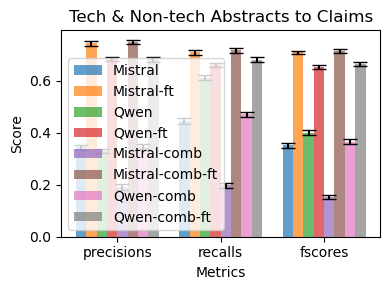

In [35]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std

results_path = '../../metrics/technontech2claims_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr_claims = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr_claims[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr_claims, 
                                  save_path='../figures/technontech2claims_comb.pdf',
                                 # name_mapping=name_mapping, 
                                  figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to Claims')

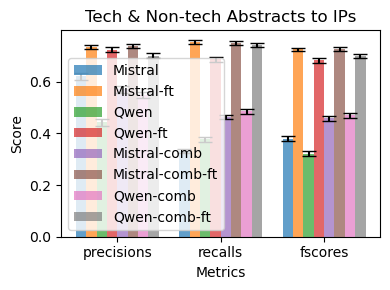

In [36]:
import os
import numpy as np
import json
from collections import defaultdict
from data_utils import load_jsonl
from vis_utils import analyze, plot_grouped_bar_adjustable_width, bootstrap_std

results_path = '../../metrics/technontech2ip_scores.json'

with open(results_path, 'rt') as input_file:
    results_all = json.load(input_file)
    
results_all_aggr_ip = {}
for key in results_all:
    aggr_results = analyze(results_all[key],
                                        metrics_keep=[
                                            'precisions',
                                            'recalls',
                                            'fscores'])
    results_all_aggr_ip[key] = aggr_results
    
# Running the function with your dataset
plot_grouped_bar_adjustable_width(results_all_aggr_ip, 
                                  save_path='../figures/technontech2ip_comb.pdf',
                                 # name_mapping=name_mapping, 
                                  figsize=(4, 3),
                                 rotation=0, ha='center',
                                 title='Tech & Non-tech Abstracts to IPs')

In [34]:
results_all_aggr_claims, results_all_aggr_ip

({'Mistral': {'precisions': (0.6217010028713976, 0.007073676705903718),
   'recalls': (0.33173667316515615, 0.0045991734446419515),
   'fscores': (0.38023638591975384, 0.005146787069933639)},
  'Mistral-ft': {'precisions': (0.7351236364577115, 0.003935151357614646),
   'recalls': (0.7538951512797488, 0.004002701579668354),
   'fscores': (0.726057573940976, 0.0035524446170680864)},
  'Qwen': {'precisions': (0.4425878427128427, 0.007160256178603616),
   'recalls': (0.3780970427448368, 0.005091841940861483),
   'fscores': (0.32106124709001044, 0.005479270858432255)},
  'Qwen-ft': {'precisions': (0.7244910867727045, 0.004455282529258907),
   'recalls': (0.6865351383695423, 0.0042781638036499415),
   'fscores': (0.6827065947718715, 0.0038169349504945044)},
  'Mistral-comb': {'precisions': (0.5713429223554224, 0.006908198978381387),
   'recalls': (0.46333671527131276, 0.004556971337161172),
   'fscores': (0.458404071793438, 0.005254639747201504)},
  'Mistral-comb-ft': {'precisions': (0.73974

In [30]:
# Assuming results_all_aggr_claims and results_all_aggr_ip are defined as in your snippet


def format_cell(cell, bold=False):
    """
    Format a cell given a tuple (mean, std) with 4 decimals.
    Optionally wrap the result in LaTeX bold formatting.
    """
    text = f"{cell[0]:.4f} $\\pm$ {cell[1]:.4f}"
    return f"\\textbf{{{text}}}" if bold else text

def best_format(cell_sep, cell_joint):
    """
    Compare the mean values from two cells (separate and joint)
    and return a tuple of formatted strings where the best (largest)
    mean is bold.
    """
    if cell_sep[0] > cell_joint[0]:
        return format_cell(cell_sep, bold=True), format_cell(cell_joint, bold=False)
    elif cell_joint[0] > cell_sep[0]:
        return format_cell(cell_sep, bold=False), format_cell(cell_joint, bold=True)
    else:
        # If equal, no bold formatting
        return format_cell(cell_sep, bold=False), format_cell(cell_joint, bold=False)

# Define a helper function that formats the cell value with 4 decimals
# and bolds the best (largest) value when comparing separate and joint.
def best_format_no_pm(cell_sep, cell_joint):
    # Extract mean values from the tuples (ignoring the std since we're not displaying it)
    sep_val = cell_sep[0]
    joint_val = cell_joint[0]
    sep_str = f"{sep_val:.4f}"
    joint_str = f"{joint_val:.4f}"
    if sep_val > joint_val:
        sep_str = f"\\textbf{{{sep_str}}}"
    elif joint_val > sep_val:
        joint_str = f"\\textbf{{{joint_str}}}"
    return sep_str, joint_str


# model = 'Mistral-ft'

for model in ['Mistral', 'Mistral-ft', 'Qwen', 'Qwen-ft']:
    try:
        comb_model = model.split('-')[0] + '-comb-' + model.split('-')[1]
    except:
        comb_model = model.split('-')[0] + '-comb'

    # print('model', model)

    # Build the table dictionary using the provided results
    table = {
        'claims': {
            'separate': {
                'P': results_all_aggr_claims[model]['precisions'],
                'R': results_all_aggr_claims[model]['recalls'],
                'F': results_all_aggr_claims[model]['fscores']
            },
            'joint': {
                'P': results_all_aggr_claims[comb_model]['precisions'],
                'R': results_all_aggr_claims[comb_model]['recalls'],
                'F': results_all_aggr_claims[comb_model]['fscores']
            }
        },
        'IP': {
            'separate': {
                'P': results_all_aggr_ip[model]['precisions'],
                'R': results_all_aggr_ip[model]['recalls'],
                'F': results_all_aggr_ip[model]['fscores']
            },
            'joint': {
                'P': results_all_aggr_ip[comb_model]['precisions'],
                'R': results_all_aggr_ip[comb_model]['recalls'],
                'F': results_all_aggr_ip[comb_model]['fscores']
            }
        }
    }

    # Prepare formatted cells for each row (claims and IP) and each metric (P, R, F)
    rows = {}
    for row in ['claims', 'IP']:
        row_data = {}
        for metric in ['P', 'R', 'F']:
            sep_cell = table[row]['separate'][metric]
            joint_cell = table[row]['joint'][metric]
            sep_formatted, joint_formatted = best_format(sep_cell, joint_cell)
            row_data[metric] = (sep_formatted, joint_formatted)
        rows[row] = row_data

    # Build the LaTeX table as a formatted string with 4 decimals and best numbers bolded
    latex_table = r"""\begin{table*}[ht]
    \centering
    \small
    \begin{tabular}{lcccccc}
    \toprule
     & \multicolumn{3}{c}{separate} & \multicolumn{3}{c}{joint} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & P & R & F & P & R & F \\
    \midrule
    claims & 
    %s & %s & %s & %s & %s & %s \\
    IP & 
    %s & %s & %s & %s & %s & %s \\
    \bottomrule
    \end{tabular}
    \caption{Performance results for model %s. The ``separate'' columns correspond to the model's individual claims/IP extraction, while the ``joint'' columns correspond to the combined extraction.}
    \label{tab:performance}
    \end{table*}""" % (
        # claims row: separate (P, R, F) and joint (P, R, F)
        rows['claims']['P'][0], rows['claims']['R'][0], rows['claims']['F'][0],
        rows['claims']['P'][1], rows['claims']['R'][1], rows['claims']['F'][1],
        # IP row: separate (P, R, F) and joint (P, R, F)
        rows['IP']['P'][0], rows['IP']['R'][0], rows['IP']['F'][0],
        rows['IP']['P'][1], rows['IP']['R'][1], rows['IP']['F'][1],
        model
    )

    # Print the LaTeX table code
    print(latex_table)
    
    print()
    print()

    

    # Compute formatted strings for each metric and each row (claims and IP)
    claims_P_sep, claims_P_joint = best_format_no_pm(table['claims']['separate']['P'],
                                                     table['claims']['joint']['P'])
    claims_R_sep, claims_R_joint = best_format_no_pm(table['claims']['separate']['R'],
                                                     table['claims']['joint']['R'])
    claims_F_sep, claims_F_joint = best_format_no_pm(table['claims']['separate']['F'],
                                                     table['claims']['joint']['F'])

    IP_P_sep, IP_P_joint = best_format_no_pm(table['IP']['separate']['P'],
                                             table['IP']['joint']['P'])
    IP_R_sep, IP_R_joint = best_format_no_pm(table['IP']['separate']['R'],
                                             table['IP']['joint']['R'])
    IP_F_sep, IP_F_joint = best_format_no_pm(table['IP']['separate']['F'],
                                             table['IP']['joint']['F'])

    # Build the LaTeX table as a formatted string (without $\pm$) and with best numbers bolded
    latex_table = r"""\begin{table*}[ht]
    \centering
    \begin{tabular}{lcccccc}
    \toprule
     & \multicolumn{3}{c}{separate} & \multicolumn{3}{c}{joint} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & P & R & F & P & R & F \\
    \midrule
    claims & 
    %s & %s & %s & %s & %s & %s \\
    IP & 
    %s & %s & %s & %s & %s & %s \\
    \bottomrule
    \end{tabular}
    \caption{Performance results for model %s. The ``separate'' columns correspond to the model's individual claims/IP extraction, while the ``joint'' columns correspond to the combined extraction.}
    \label{tab:performance}
    \end{table*}""" % (
        # claims row: separate and joint values for P, R, F
        claims_P_sep, claims_R_sep, claims_F_sep,
        claims_P_joint, claims_R_joint, claims_F_joint,
        # IP row: separate and joint values for P, R, F
        IP_P_sep, IP_R_sep, IP_F_sep,
        IP_P_joint, IP_R_joint, IP_F_joint,
        model
    )

    # Print the final LaTeX table code
    print(latex_table)
    
    print()
    print()


\begin{table*}[ht]
    \centering
    \small
    \begin{tabular}{lcccccc}
    \toprule
     & \multicolumn{3}{c}{separate} & \multicolumn{3}{c}{joint} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7}
     & P & R & F & P & R & F \\
    \midrule
    claims & 
    \textbf{0.3438 $\pm$ 0.0056} & \textbf{0.4451 $\pm$ 0.0056} & \textbf{0.3516 $\pm$ 0.0051} & 0.1908 $\pm$ 0.0053 & 0.1975 $\pm$ 0.0044 & 0.1522 $\pm$ 0.0042 \\
    IP & 
    \textbf{0.6217 $\pm$ 0.0069} & 0.3317 $\pm$ 0.0046 & 0.3802 $\pm$ 0.0052 & 0.5713 $\pm$ 0.0066 & \textbf{0.4633 $\pm$ 0.0047} & \textbf{0.4584 $\pm$ 0.0050} \\
    \bottomrule
    \end{tabular}
    \caption{Performance results for model Mistral. The ``separate'' columns correspond to the model's individual claims/IP extraction, while the ``joint'' columns correspond to the combined extraction.}
    \label{tab:performance}
    \end{table*}


\begin{table*}[ht]
    \centering
    \begin{tabular}{lcccccc}
    \toprule
     & \multicolumn{3}{c}{separate} & \multico